Importing the libraries and loading the dataset

In [52]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Set style
sns.set(style="whitegrid")

#save folder
save_folder = "eda_plots"
os.makedirs(save_folder, exist_ok=True)


#### Load data

In [53]:
df = pd.read_csv("/Users/niharikabisoyi/PyCharmMiscProject/UsedCarPricePrediction/data/cars.csv")
print(f"Dataset Shape: {df.shape}")
df.head(5)

Dataset Shape: (762091, 20)


,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


Dataset contains ~762K records and 20 features

#### **Dataset** **Overview**

In [54]:
print("\n--- INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())

print("\n--- MISSING VALUES (%) ---")
print((df.isnull().mean() * 100).round(2))

print("\n--- DUPLICATES ---")
print(df.duplicated().sum())


print(f"{df.duplicated().mean() * 100:.2f}% duplicate rows")


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762091 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   manufacturer         762091 non-null  object 
 1   model                762091 non-null  object 
 2   year                 762091 non-null  int64  
 3   mileage              761585 non-null  float64
 4   engine               747041 non-null  object 
 5   transmission         752187 non-null  object 
 6   drivetrain           740529 non-null  object 
 7   fuel_type            739164 non-null  object 
 8   mpg                  620020 non-null  object 
 9   exterior_color       753232 non-null  object 
 10  interior_color       705116 non-null  object 
 11  accidents_or_damage  737879 non-null  float64
 12  one_owner            730608 non-null  float64
 13  personal_use_only    737239 non-null  float64
 14  seller_name          753498 non-null  object 
 15  sel

Certain features as mpg(18.6%),seller_rating(28%) and price_drop(46%) contain very higher percentage of missing values

#### Data Cleaning

#### Column Standardization

In [55]:
#Capitalize the feature names
df.columns = (
    df.columns
    .str.strip()
    .str.replace('_', ' ')
    .str.title()
)


#### Remove Duplicates

In [56]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 9145


#### Missing Value Handling

Numerical features: fill with median

In [57]:
num_cols = ['Mileage',"Accidents Or Damage","One Owner","Personal Use Only","Seller Rating","Driver Rating",]

for col in num_cols:
    median = df[col].median()
    df[col] = df[col].fillna(median)

Categorical features: fill with mode.As mode() returns a series, it takes the  first valueand returns.

In [58]:
cat_cols = ["Engine","Transmission","Drivetrain","Fuel Type","Exterior Color","Seller Name"]

for col in cat_cols:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)

The dataset contain 9145 duplicate rows, approximately 1.2% of the total records. We will remove them to maintain data integrity.

we will check all the unique values and counts of each categorical feature

In [59]:
df.select_dtypes(include='object').nunique()

Manufacturer         30
Model             12187
Engine             6903
Transmission       1313
Drivetrain           33
Fuel Type            36
Mpg                 865
Exterior Color     7681
Interior Color     4679
Seller Name       18254
dtype: int64

In [60]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col} → Unique Values: {df[col].unique()}")
    print(f"Counts:\n{df[col].value_counts()}\n")

Manufacturer → Unique Values: ['Acura' 'Audi' 'BMW' 'Buick' 'Cadillac' 'Chevrolet' 'Chrysler' 'Dodge'
 'Ford' 'GMC' 'Honda' 'Hyundai' 'INFINITI' 'Jaguar' 'Jeep' 'Kia'
 'Land Rover' 'Lexus' 'Lincoln' 'Mazda' 'Mercedes-Benz' 'Mitsubishi'
 'Nissan' 'Porsche' 'RAM' 'Subaru' 'Tesla' 'Toyota' 'Volkswagen' 'Volvo']
Counts:
Manufacturer
Ford             78851
Toyota           59155
Chevrolet        55485
Nissan           47809
Jeep             41192
Mercedes-Benz    40461
Honda            37264
BMW              37077
Kia              34511
GMC              29176
Dodge            24772
Subaru           24367
Volkswagen       24290
Hyundai          22057
Lexus            20906
RAM              19278
Audi             17717
Cadillac         17472
Mazda            15250
Buick            14332
Chrysler         12249
Land Rover       12153
INFINITI         12101
Porsche          11310
Lincoln          10554
Volvo             9948
Acura             8259
Tesla             5823
Mitsubishi        5678
Ja

#### Feature Engineering

In [61]:
print("Before:", print(df['Manufacturer'].nunique()))
top_manufacturer = df['Manufacturer'].value_counts().head(20).index
df['Manufacturer'] = df['Manufacturer'].apply(lambda x: x if x in top_manufacturer else 'Other')
print(df['Manufacturer'].value_counts().head(5))
print("After:", print(df['Manufacturer'].nunique()))

30
Before: None
Manufacturer
Other        91524
Ford         78851
Toyota       59155
Chevrolet    55485
Nissan       47809
Name: count, dtype: int64
21
After: None


We kept top 20 manufacturers and rest as others to improve model performance.

In [62]:
print("Before:",df['Model'].nunique())
#We will keep top 20 models and replace the rest as Other.
top_models = df['Model'].value_counts().nlargest(20).index
df['Model'] = df['Model'].apply(lambda x: x if x in top_models else 'Other')

print("After:",df['Model'].nunique())

Before: 12187
After: 21


- The original `Model` column had **12,187 unique values**, which is too high for modeling and would result in sparse one-hot encoded features.
- To reduce dimensionality and focus on the most common car models, we kept the **top 20 most frequent models** and replaced the rest with `"Other"`.
- This reduces noise and helps machine learning models generalize better.

**Result:**
- Before: 12,187 unique models
- After: 21 unique models (top 20 + Other)

In [63]:
print("Before:", df['Engine'].nunique())
print(df['Engine'].value_counts().head(5))
#let's extract numeric values from 'Engine'
df['Engine_Size'] = df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)

print("After:", df['Engine'].nunique())

Before: 6903
Engine
2.0L I4 16V GDI DOHC Turbo    89278
3.6L V6 24V MPFI DOHC         34804
3.6L V6 24V GDI DOHC          26644
2.0L I4 16V MPFI DOHC         19328
1.5L I4 16V GDI DOHC Turbo    18151
Name: count, dtype: int64
After: 6903


- The original `Engine` column had **6,903 unique values**, containing text descriptions like `"2.0L I4"` or `"3.5L V6"`.
- Many of these values were redundant or inconsistent, making it difficult for models to use directly.
- To create a meaningful numeric feature, we **extracted the engine size in liters** from the text using regex.
- This new feature, `Engine_Size`, represents the **numeric engine capacity** and can be directly used in machine learning models.

**Result:**
- Before: 6,903 unique engine descriptions
- After: 519 unique numeric engine sizes

In [64]:
print("Before:",df['Transmission'].nunique())
print(df['Transmission'].value_counts())

df['Transmission_clean'] = df['Transmission'].str.extract(r'(Automatic|Manual|CVT|Semi-Automatic|Other)', expand=False)
df['Transmission_clean'] = df['Transmission_clean'].fillna('Other')
print(df['Transmission_clean'].value_counts())

print("After:",df['Transmission_clean'].nunique())

Before: 1313
Transmission
6-Speed Automatic              156458
8-Speed Automatic              137968
Automatic CVT                  107290
Automatic                       95940
9-Speed Automatic               60410
                                ...  
SINGLE SPEED TRANSMISSION           1
Rebuilt 3 Speed Auto                1
4-tomatic 2 Speed Automatic         1
Top Load 4-Speed Manual             1
9Speed AT                           1
Name: count, Length: 1313, dtype: int64
Transmission_clean
Automatic         703765
Other              23607
Manual             22687
CVT                 2886
Semi-Automatic         1
Name: count, dtype: int64
After: 5


- The original `Transmission` column had **1,313 unique values**, including various descriptive text like `"Automatic 6-Spd"` or `"Manual 5-Speed"`.
- Such high cardinality and inconsistent naming make it difficult for machine learning models to interpret.
- To simplify, we **extracted the main transmission types** (`Automatic`, `Manual`, `CVT`, `Semi-Automatic`) and labeled all other variations as `Other`.
- Missing values were also filled with `Other`.

**Result:**
- Before: 1,313 unique transmission types
- After: 5 cleaned categories (`Automatic`, `Manual`, `CVT`, `Semi-Automatic`, `Other`)

In [65]:
print("Before:",df['Drivetrain'].nunique())
print(df['Drivetrain'].value_counts())
df['Drivetrain'] = df['Drivetrain'].apply(
    lambda x: x if str(x).strip() in ['4WD', 'AWD', 'RWD', 'FWD'] else 'Other'
)
print("After:",df['Drivetrain'].nunique())

Before: 33
Drivetrain
Front-wheel Drive                                              259419
All-wheel Drive                                                227752
Four-wheel Drive                                               155512
Rear-wheel Drive                                                96461
FWD                                                              6245
AWD                                                              3424
4WD                                                              1834
RWD                                                              1698
All-Wheel Drive                                                   115
Unknown                                                           102
Front-Wheel Drive                                                  97
Front-Wheel Drive with Limited-Slip Differential                   42
Four-Wheel Drive                                                   37
Four-Wheel Drive with Locking and Limited-Slip Differential        3

- The original `Drivetrain` column had **33 unique values**, including rare or inconsistent entries like `"All Wheel Drive"` or `"Front Wheel Drive"`.
- To simplify and make it model-ready, we **kept the main drivetrain types** (`4WD`, `AWD`, `RWD`, `FWD`) and labeled all other variations as `Other`.

**Result:**
- Before: 33 unique drivetrain types
- After: 5 cleaned categories (`4WD`, `AWD`, `RWD`, `FWD`, `Other`)

We will convert each value to string, remove spaces, if value is ['4WD', 'AWD', 'RWD', 'FWD'], keep it, and replace rest as Other

In [66]:
print("Before:",df['Fuel Type'].nunique())
#Main categories to keep
main_fuels = ['Gasoline','Hybrid','Diesel','E85 Flex Fuel','Electric','Plug-In Hybrid']

#map other varieties to main categories
fuel_map = {
    'Gasoline Fuel': 'Gasoline',
    'Gasoline/Mild Electric Hybrid': 'Hybrid',
    'Regular Unleaded': 'Gasoline',
    'Premium Unleaded': 'Gasoline',
    'Gas': 'Gasoline',
    'Hybrid Fuel': 'Hybrid',
    'Diesel Fuel': 'Diesel',
    'Plug-In Electric/Gas': 'Plug-In Hybrid',
    'Gas/Electric Hybrid': 'Hybrid',
    'E85 Fl': 'E85 Flex Fuel',
    'Flexible Fuel': 'E85 Flex Fuel',
    'Flex Fuel': 'E85 Flex Fuel',
    'Flex Fuel Capability': 'E85 Flex Fuel',
    'Electric Fuel System': 'Electric',
    'Premium (Required)': 'Gasoline',
    'Premium': 'Gasoline',
}
#Apply mapping Other varieties will become other
df['Fuel Type'] = df['Fuel Type'].replace(fuel_map).apply(lambda x: x if x in main_fuels else 'Other')
df['Fuel Type'].value_counts()

print("After:",df['Fuel Type'].nunique())

Before: 36
After: 7


- The original `Fuel Type` column had **36 unique values**, including rare variants and inconsistent labels (e.g., `"Gasoline/Mild Electric Hybrid"`, `"E85 Fl"`, `"Electric Fuel System"`).
- To standardize the data, we **mapped similar varieties to 6 main categories**:
  `Gasoline`, `Hybrid`, `Diesel`, `E85 Flex Fuel`, `Electric`, `Plug-In Hybrid`.
- All other rare fuel types were labeled as `Other`.

**Result:**
- Before: 36 unique fuel types
- After: 7 cleaned categories (`Gasoline`, `Hybrid`, `Diesel`, `E85 Flex Fuel`, `Electric`, `Plug-In Hybrid`, `Other`)

In [67]:
print("Before:",df['Mpg'].nunique())
print(df['Mpg'].value_counts().head(5))

df['Mpg_Clean'] = df['Mpg'].apply(lambda x: np.nan if pd.isna(x) else np.mean([float(n) for n in str(x).split('-')]))

print("After:",df['Mpg_Clean'].nunique())

Before: 865
Mpg
19-26    15955
18-25    15567
17-25    14092
20-27    13363
16-23    11369
Name: count, dtype: int64
After: 158


- The original `Mpg` column contained **865 unique values**, including ranges like `"19-26"` and some missing values.
- To standardize the feature for modeling, we **converted ranges into numeric averages** and retained `NaN` for missing values.

**Example:**
- `"19-26"` → 22.5

**Result:**
- Before: 865 unique values
- After: 158 cleaned numeric values in `Mpg_Clean`

we will  map common colors into one and rare colors with counts < 4000 to Other.

In [68]:
print("Before:",df['Exterior Color'].nunique())
print(df['Exterior Color'].value_counts().head(10))
# Define mapping for common variations
color_map = {
    'Summit White':'White',
    'Bright White Clearcoat':'White',
    'Oxford White':'White',
    'Polar White':'White',
    'Alpine White':'White',
    'Pure White':'White',
    'Gun Metallic':'Gray',
    'Granite Crystal Clearcoat Metallic':'Gray',
    'Billet Silver Metallic Clearcoat':'Silver',
    'Silver Ice Metallic':'Silver',
    'Black Sapphire Metallic':'Black',
    'Onyx Black':'Black',
    'Satin Steel Metallic':'Gray',
    'Crystal Black Pearl':'Black'
}
# Replace common variations and fill NaN
df['Exterior Color'] = df['Exterior Color'].fillna('Unknown').replace(color_map)

# Group rare colors into 'Other'
counts = df['Exterior Color'].value_counts()
top_colors = counts[counts >= 4000].index
df['Exterior Color'] = df['Exterior Color'].apply(lambda x: x if x in top_colors else 'Other')

print("After:",df['Exterior Color'].nunique())

Before: 7681
Exterior Color
Black                     68284
White                     50526
Gray                      29902
Silver                    24061
Blue                      17268
Summit White              16578
Red                       15045
Bright White Clearcoat    13549
Oxford White               8184
Gun Metallic               7691
Name: count, dtype: int64
After: 9


- The original `Exterior Color` column contained **7,681 unique values**, including many rare variations and inconsistencies (e.g., `'Summit White'`, `'Bright White Clearcoat'`).
- To standardize this feature:
  1. **Mapped common color variations** to a single representative color (e.g., all shades of white → `'White'`).
  2. **Filled missing values** with `'Unknown'`.
  3. **Grouped rare colors** (counts < 4000) into `'Other'`.

**Result:**
- Before: 7,681 unique values
- After: 10 standardized categories

In [69]:
print("Before:",df['Interior Color'].nunique())
print(df['Interior Color'].value_counts().head(5))
top_interior = df['Interior Color'].value_counts().nlargest(20).index

# Replace rare colors with 'Other'
df['Interior Color'] = df['Interior Color'].apply(lambda x: x if x in top_interior else 'Other')
print("After:",df['Interior Color'].nunique())

Before: 4679
Interior Color
Black        283070
Gray          49365
Jet Black     45644
Ebony         37349
Charcoal      25836
Name: count, dtype: int64
After: 21


The original `Interior Color` column contained **many unique values**, including numerous rare or inconsistent variations (e.g., `'Black Leather'`, `'Beige Cloth'`).
- To standardize this feature:
  1. **Identified the top 20 most common interior colors**.
  2. **Replaced all rare colors** (not in the top 20) with `'Other'`.

**Result:**
- Before: many unique values
- After: 21 categories (top 20 colors + `'Other'`)

In [70]:
print("Before:",df['Seller Name'].nunique())
# Top 30 most frequent sellers
top_sellers = df['Seller Name'].value_counts().nlargest(30).index

# Replace all other sellers with 'Other'
df['Seller Name'] = df['Seller Name'].apply(lambda x: x if x in top_sellers else 'Other')

print("After:",df['Seller Name'].nunique())

Before: 18254
After: 31


The original `Seller Name` column contained **many unique values**, including numerous sellers with very few listings.
- To standardize this feature:
  1. **Identified the top 30 most frequent sellers**.
  2. **Replaced all other sellers** (not in the top 30) with `'Other'`.

**Result:**
- Before: many unique values
- After: 31 categories (top 30 sellers + `'Other'`)

#### Feature Extraction

In [71]:
current_year = 2026
df["Vehicle_Age"] = current_year - df["Year"]

In [72]:
df["Mileage_per_Year"] = df["Mileage"] / df["Vehicle_Age"]
df['Mileage_per_Year'] = df['Mileage_per_Year'].round(2)

#### Dropping Features
Dropping unnecessary columns as we already have extracted data from Engine, Mpg.

In [73]:
df.drop(columns=['Year','Transmission','Engine','Mpg','Price Drop'],inplace=True)

Final check for missing values and duplicates

We will save the cleaned dataframe to  a new csv file.

In [74]:
df.to_csv("/Users/niharikabisoyi/PyCharmMiscProject/UsedCarPricePrediction/data/cars_cleaned.csv", index=False)

#### Data Exploration & Visualization

**Target Variable Analysis**:

We will apply log tranformation to the price variableas as we are heavily right skewed with extreme outliers, to reduce skewness and normalize distribution.

In [75]:
print("Original Skewness:", df['Price'].skew())
print(df['Price'].describe())
print(df['Price'].sort_values(ascending=False).head(5))

# Remove extreme outliers using IQR
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print(f"IQR upper bound: {upper}")

# Filter out unrealistic prices
df = df[(df['Price'] > 1000) & (df['Price'] <= upper)]

# Check skewness after outlier removal
print("Skewness after outlier removal:", df['Price'].skew())

# Apply log transformation to reduce skewness and stabilize variance
df['Price_log'] = np.log1p(df['Price'])

# Check skewness after log transformation
print("Skewness after log transformation:", df['Price_log'].skew())

Original Skewness: 613.3258202230932
count    7.529460e+05
mean     3.520899e+04
std      1.629960e+06
min      1.000000e+00
25%      1.959500e+04
50%      2.799000e+04
75%      3.948800e+04
max      1.000000e+09
Name: Price, dtype: float64
108142    1.000000e+09
188113    1.000000e+09
224571    8.888889e+06
84358     4.999999e+06
636956    3.490000e+06
Name: Price, dtype: float64
IQR upper bound: 69327.5
Skewness after outlier removal: 0.6356118009715532
Skewness after log transformation: -0.6652796370659634


The Price variable was highly right-skewed (skewness = 613) with unrealistic outliers (e.g., $1B, $8M). Extreme values were removed using the IQR method to ensure data quality and improve model learning for typical vehicles. A log transformation (np.log1p) was then applied to reduce skewness and create a more symmetric distribution for modeling.

##### Price distribution before and after log tranformation

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original price distribution
sns.histplot(df['Price'], bins=30, ax=axes[0])
axes[0].set_title('Original Price Distribution')
plt.savefig(f"{save_folder}/price_distribution.png", dpi=300)

# Log transformed price
sns.histplot(df['Price_log'], bins=50, ax=axes[1])
axes[1].set_title('Log Transformed Price Distribution')
plt.savefig(f"{save_folder}/price_log_distribution.png", dpi=300)

plt.tight_layout()
plt.close()

The original price distribution was highly right-skewed due to a few expensive vehicles.After applying log transformation, the price distribution became more symmetric, reducing the impact of extreme outliers.

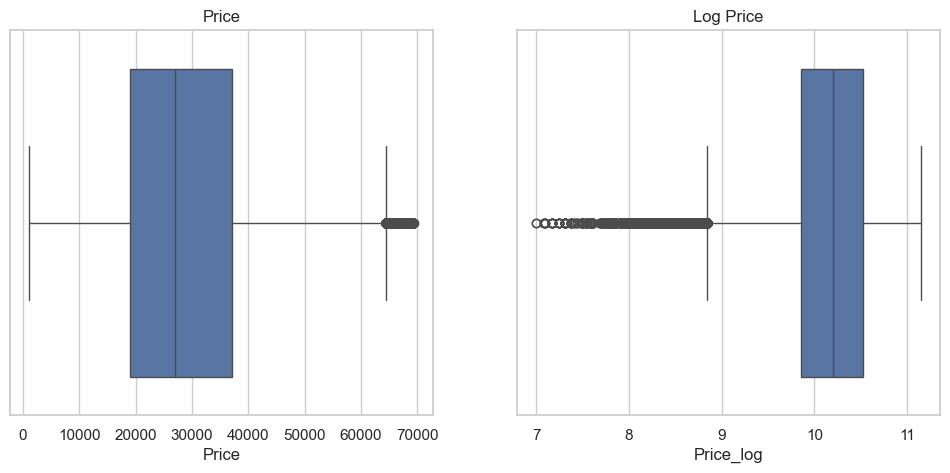

In [77]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(x=df['Price'], ax=axes[0])
axes[0].set_title("Price")

sns.boxplot(x=df['Price_log'], ax=axes[1])
axes[1].set_title("Log Price")

plt.show()

##### Price Outlier

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot( y=df["Price_log"])

plt.title("Price Outlier Visualization")
plt.ylabel("Price")

plt.tight_layout()
plt.savefig(f"{save_folder}/price_outliers.png")
plt.close()

 The majority(50%) of vehicles fall between log prices of 9.8 and 10.5 ($18k–$36k), while a few lower-priced vehicles appear as outliers(cheap cars) below log price 8.9($1k-$7.3k).

#### Categorical Feature Analysis

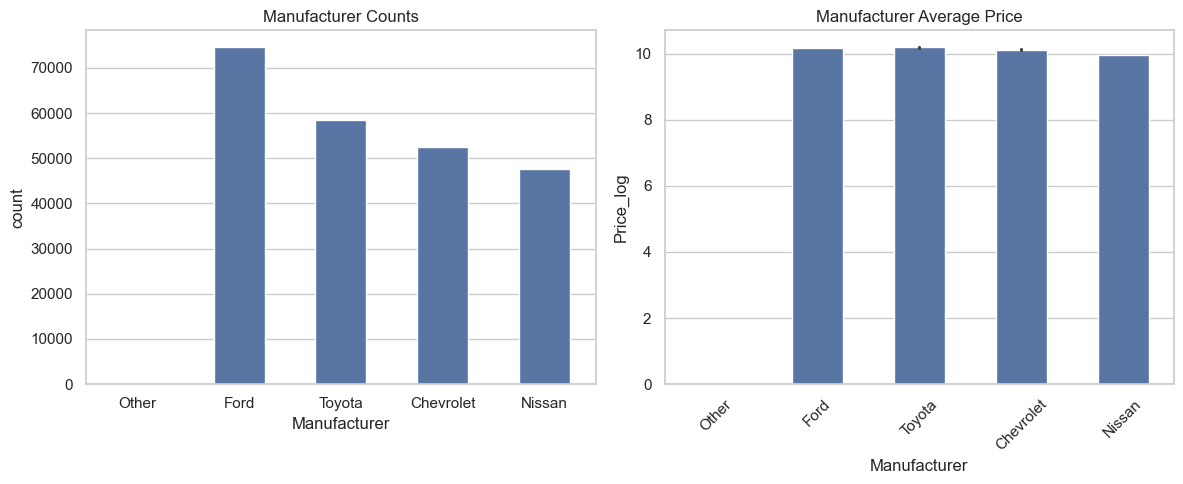

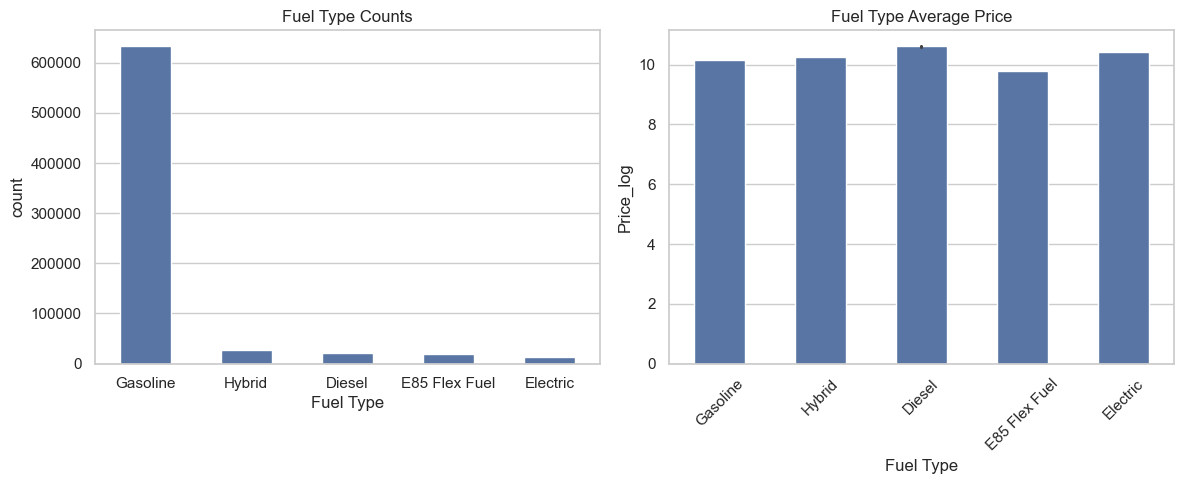

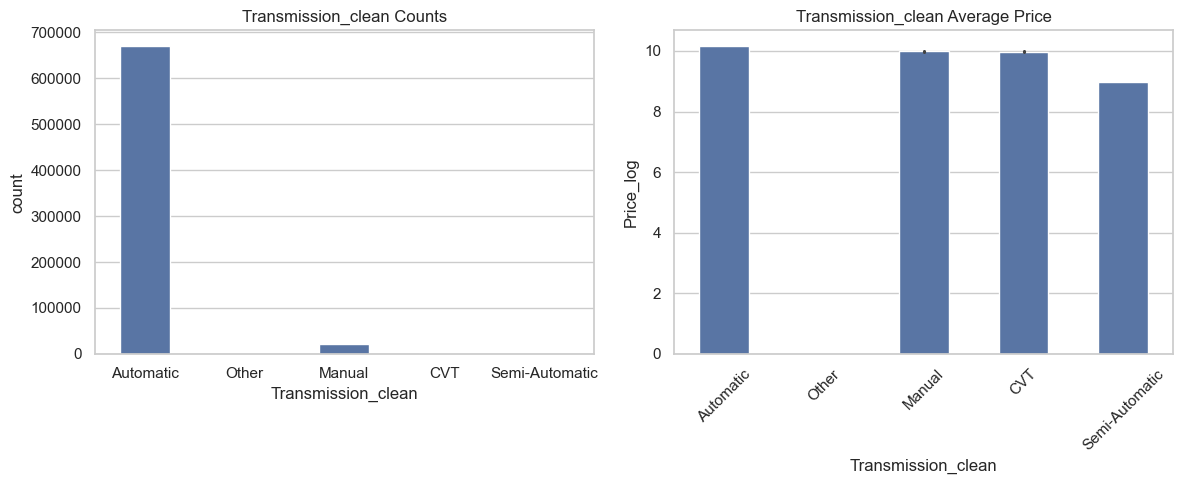

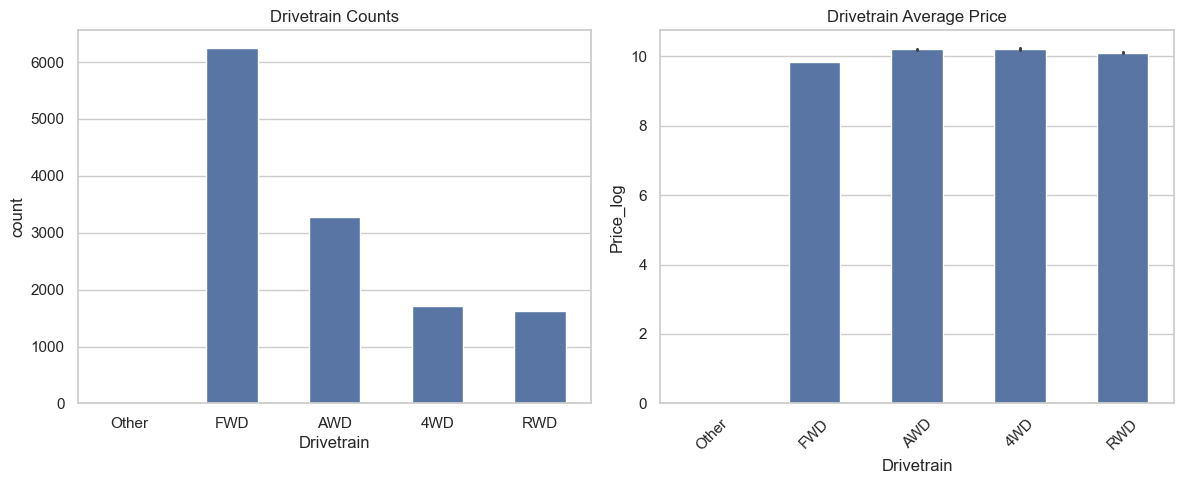

In [82]:
cat_features = ['Manufacturer','Fuel Type','Transmission_clean','Drivetrain']
for col in cat_features:
        plot_data = df[df[col] != 'Other']

        fig, axes = plt.subplots(1,2, figsize=(12,5))

        #we will exclude 'other' in drivetrain as it dominates
        sns.countplot(x= col, data= plot_data,ax=axes[0],width = 0.5, order=df[col].value_counts().index[:5])
        axes[0].set_title(f"{col} Counts")

        sns.barplot(x= col, y='Price_log', data= plot_data, ax=axes[1],width = 0.5, order=df[col].value_counts().index[:5])
        axes[1].set_title(f"{col} Average Price")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

#### Boxplot analysis

In [83]:
categorical_features = ['Manufacturer','Model','Drivetrain','Fuel Type','Transmission_clean']
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y='Price_log', data=df, showfliers=False)
    plt.title(f'Price_log vs {col}')
    plt.xticks(rotation=45)
    plt.savefig(f"{save_folder}/Boxplot distribution.png", dpi=300)
    plt.close()

##### **Numerical features Analysis**:
Lets understand distribution of numeric features to detect skewness and outliers.

1.45


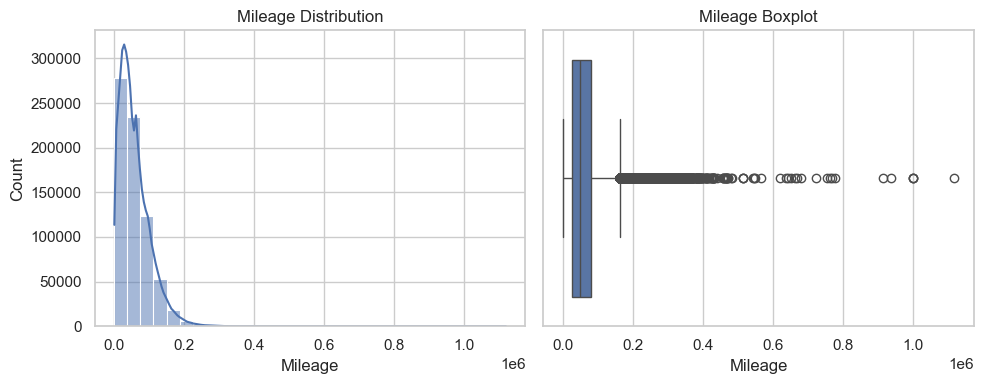

4.67


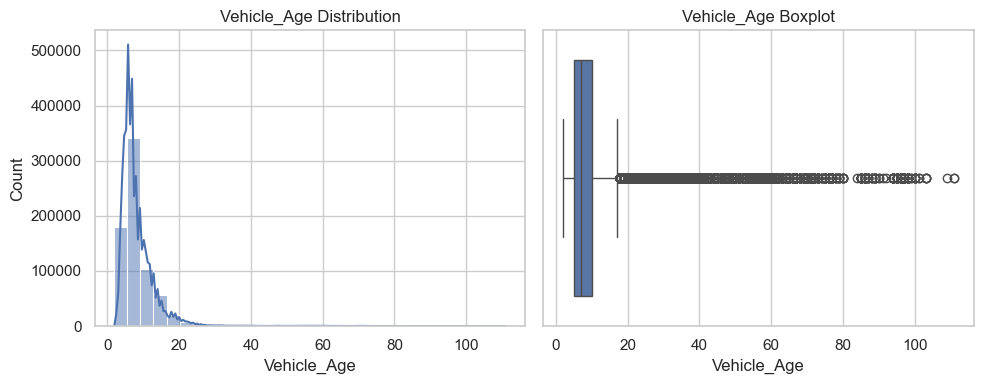

-1.96


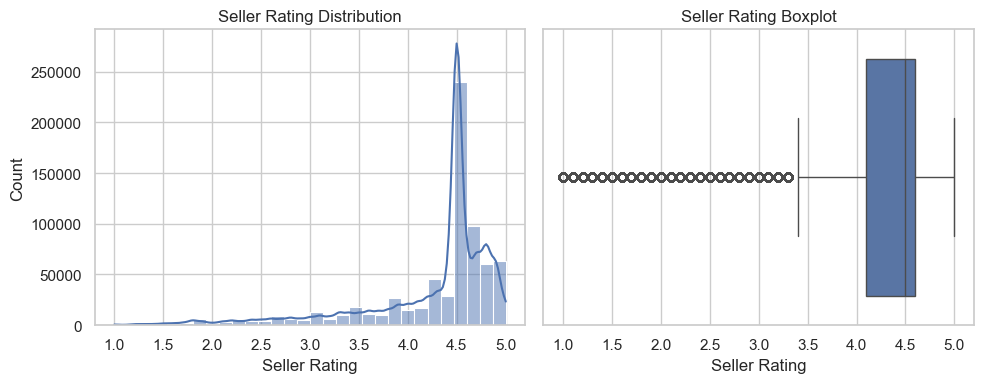

-2.86


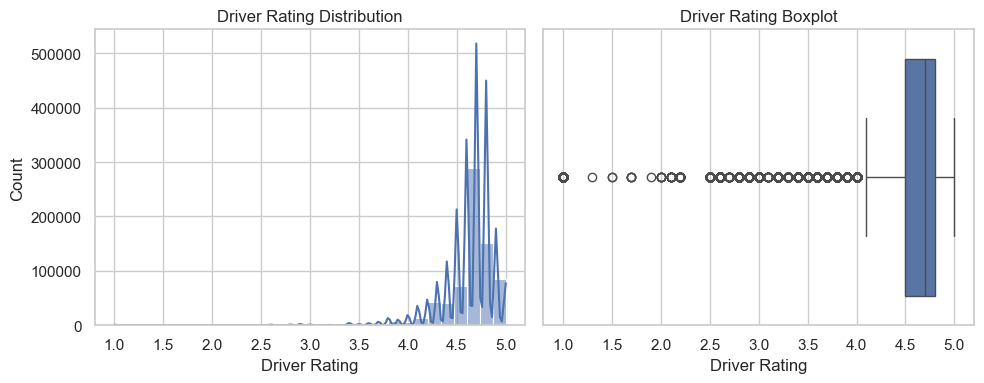

2.66


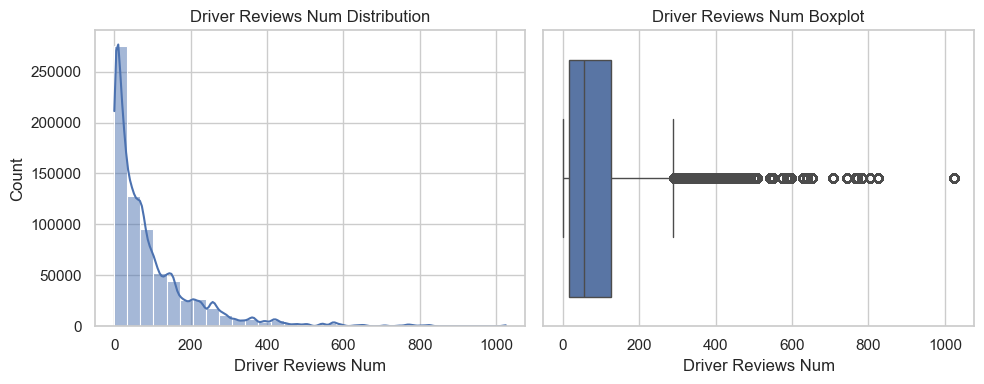

1.26


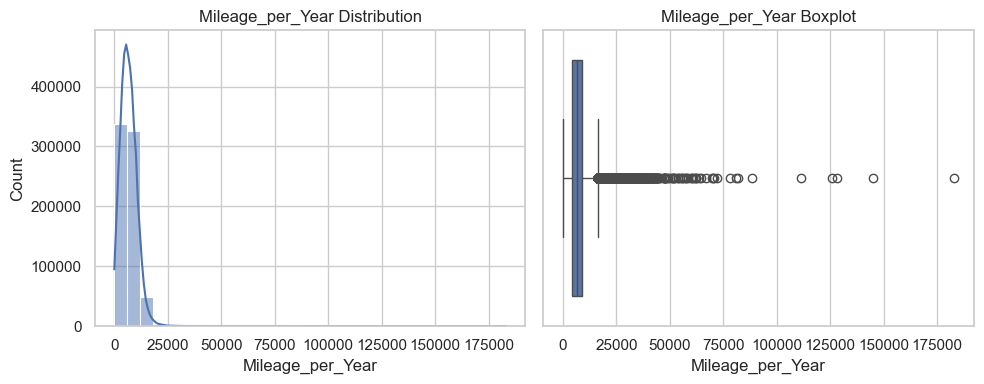

0.52


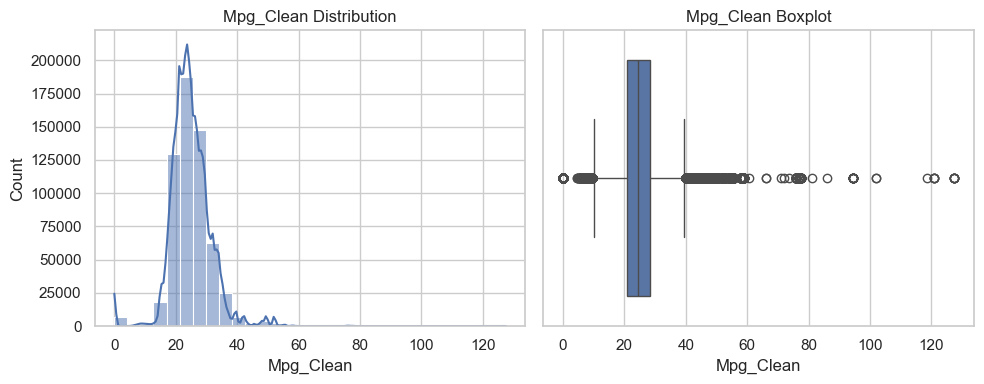

In [84]:
def plot_numeric(df):
    num_cols =  ['Mileage','Vehicle_Age','Seller Rating','Driver Rating','Driver Reviews Num','Mileage_per_Year','Mpg_Clean']
    for col in num_cols:
        print(df[col].skew().round(2))
        fig, axes = plt.subplots(1, 2, figsize=(10,4))

        #Histogram
        sns.histplot(x= df[col], kde =True,bins=30,ax=axes[0])
        axes[0].set_title(f"{col} Distribution")

        #Boxplot
        sns.boxplot(x=df[col], ax= axes[1])
        axes[1].set_title(f"{col} Boxplot")

        plt.tight_layout()
        plt.savefig(f"{save_folder}/numerical distribution.png", dpi=300)
        plt.show()

plot_numeric(df)

#### Insights:

* Visualized numeric features with histograms and boxplots to inspect distributions and outliers.

* Identified right-skewed features that could affect model performance.

* **Next step**: apply np.log1p() to reduce skewness and stabilize variance.

#### Log tranformation

We will apply log transformation to make it symmetrical.

In [85]:
df['Vehicle_Age_log'] = np.log1p(df['Vehicle_Age'])
df['Driver_Reviews_Num_log'] = np.log1p(df['Driver Reviews Num'])
df['Mileage_per_Year_log'] = np.log1p(df['Mileage_per_Year'])

In [86]:
for col in ['Vehicle_Age_log', 'Mileage_per_Year_log', 'Driver_Reviews_Num_log']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'{col} distribution (after log transformation)',fontsize=9)
    plt.close()

* Applied np.log1p() to right-skewed features: Vehicle_Age, Mileage_per_Year, Driver_Reviews_Num.

* This reduces skewness, stabilizes variance, and makes distributions more symmetric.

* Re-plotted the transformed features to confirm they are now easier for machine learning models to handle.

**Result**:

* Features previously right-skewed now have a more balanced distribution with less outliers.


#Saving the dataframe after all transformations

In [87]:
df.to_csv('/Users/niharikabisoyi/PyCharmMiscProject/UsedCarPricePrediction/data/cars_featured.csv', index=False)

#### Binary features

Accidents Or Damage
0.0    77.11
1.0    22.89
Name: proportion, dtype: float64


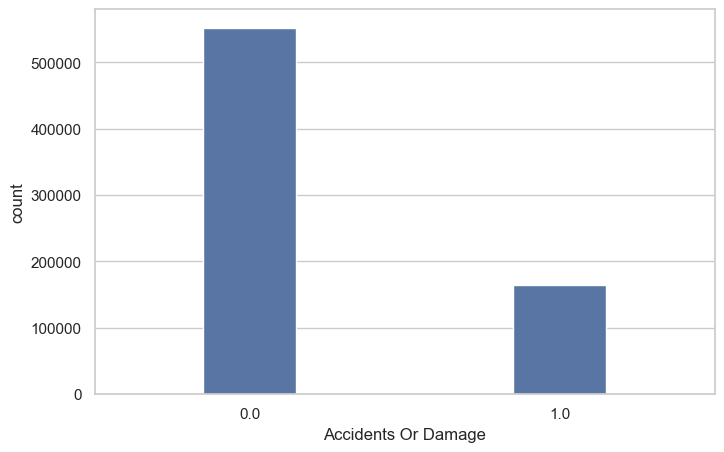

One Owner
1.0    57.44
0.0    42.56
Name: proportion, dtype: float64


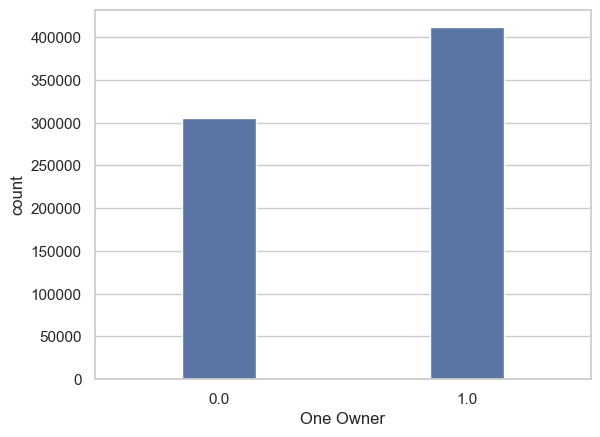

Personal Use Only
1.0    66.56
0.0    33.44
Name: proportion, dtype: float64


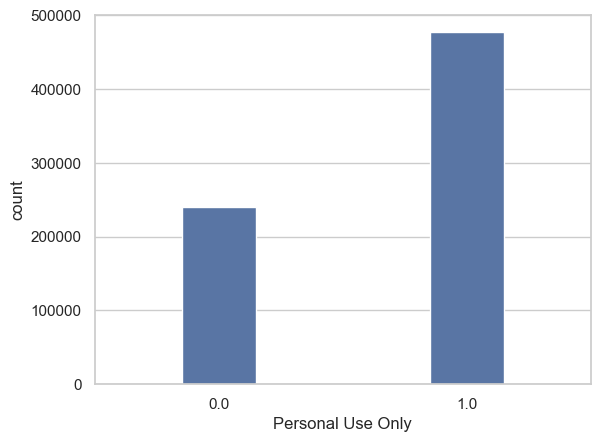

In [88]:
def plot_binary(df):
    plt.figure(figsize=(8,5))
    bin_cols = ['Accidents Or Damage','One Owner','Personal Use Only']
    for col in bin_cols:
         print((df[col].value_counts(normalize=True)*100).round(2))

         sns.countplot(x=col, data=df, width = 0.3)
         plt.savefig(f"{save_folder}/binary_distribution.png", dpi=300)
         plt.show()

plot_binary(df)

* 77% of cars did not have any accident history.

* 42% cars had only one owner which is good for resale.
* Around 66% of vehicles in the dataset were used for personal purposes, while about 33% were used for other purposes

#### Numeric vs Price

Mileage vs Price

In [89]:
plt.figure(figsize=(8,5))

sns.scatterplot( x=df["Mileage"],y=df["Price_log"])

plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.tight_layout()
plt.savefig(f"{save_folder}/mileage_vs_price.png")
plt.close()

Year vs Price

In [90]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["Vehicle_Age"], y=df["Price_log"])

plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.tight_layout()
plt.savefig(f"{save_folder}/year_vs_price.png")
plt.close()

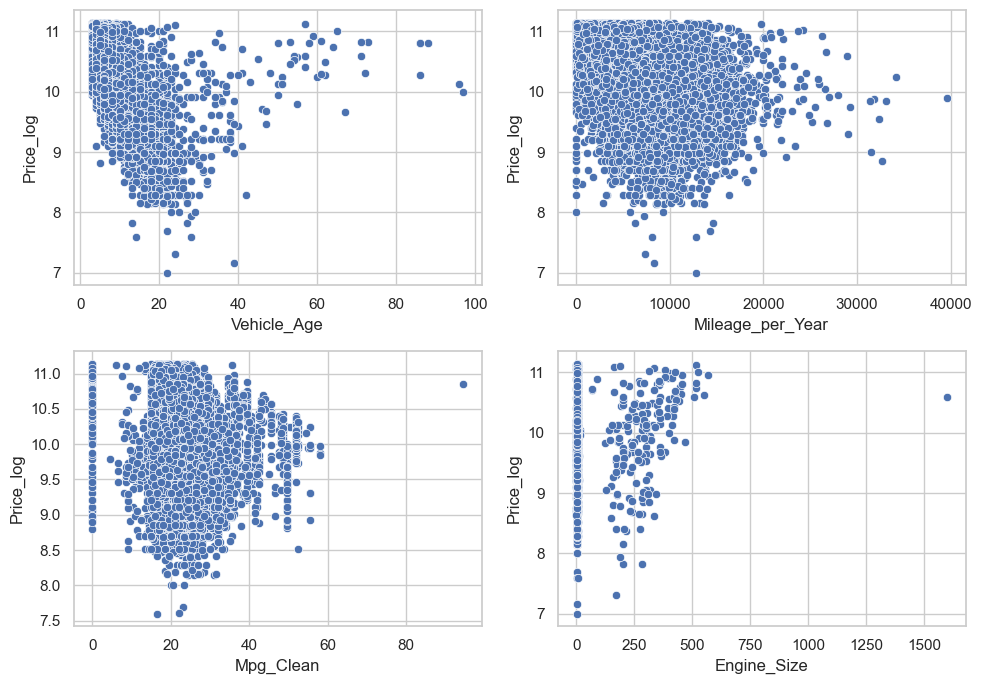

In [91]:
def plot_numeric_vs_target():
          #sample of dataset
          df_sample = df.sample(20000)

          fig, axes = plt.subplots(2, 2, figsize=(10, 7))

          sns.scatterplot(x='Vehicle_Age', y='Price_log', data=df_sample, ax=axes[0,0])
          sns.scatterplot(x='Mileage_per_Year', y='Price_log', data=df_sample, ax=axes[0,1])
          sns.scatterplot(x='Mpg_Clean', y='Price_log', data=df_sample, ax=axes[1,0])
          sns.scatterplot(x='Engine_Size', y='Price_log', data=df_sample, ax=axes[1,1])

          plt.tight_layout()
          plt.savefig(f"{save_folder}/numeric vs target.png", dpi=300)
          plt.show()

plot_numeric_vs_target()

#### Relationship between numeric feature and target with a trend line:

In [95]:
def reg_plot():
          #sample of dataset
          df_sample = df.sample(20000)

          fig, axes = plt.subplots(2, 2, figsize=(8,5))

          sns.regplot(x='Vehicle_Age', y='Price_log', data=df_sample, ax=axes[0,0])
          sns.regplot(x='Mileage_per_Year', y='Price_log', data=df_sample, ax=axes[0,1])
          sns.regplot(x='Mpg_Clean', y='Price_log', data=df_sample, ax=axes[1,0])
          sns.regplot(x='Engine_Size', y='Price_log', data=df_sample, ax=axes[1,1])

          plt.tight_layout()
          plt.savefig(f"{save_folder}/regplot.png", dpi=300)
          plt.close()

reg_plot()

The regression plots show a negative relationship between vehicle age, mileage per year, engine size, and MPG with price. This suggests that vehicles that are older, driven more frequently, or have larger engines tend to have lower resale prices.

#### Binary vs Target

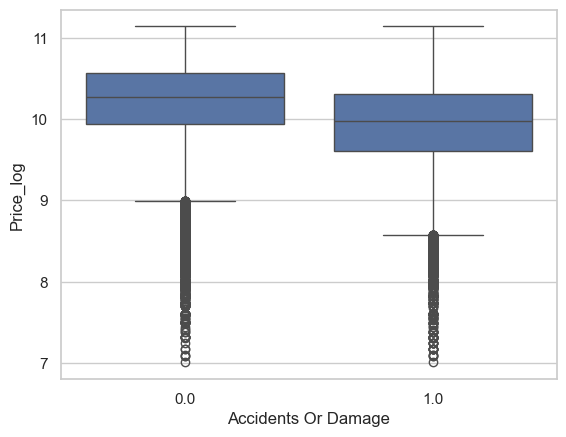

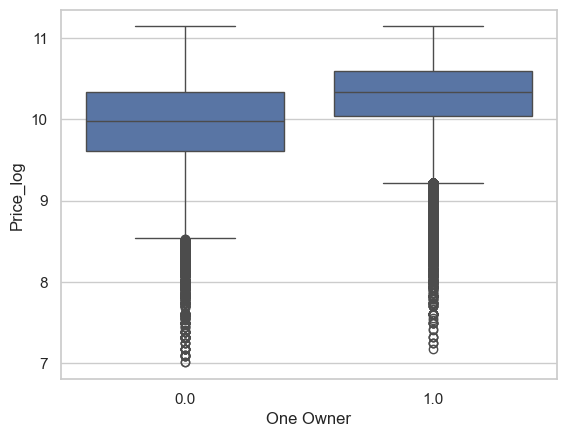

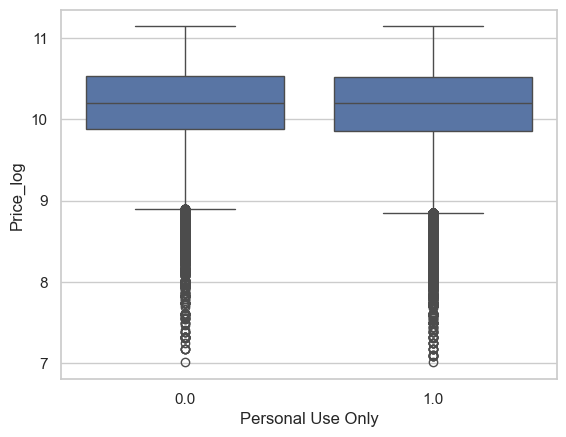

In [96]:
def plot_bin_tar():
    bin_cols = ['Accidents Or Damage','One Owner','Personal Use Only']
    for col in bin_cols:
            sns.boxplot(x=col, y='Price_log', data=df)
            plt.show()
plot_bin_tar()

#### Brand-wise Price Comparison

In [99]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df["Manufacturer"],y=df["Price_log"])

plt.xticks(rotation=45)

plt.title("Brand-wise Price Comparison")
plt.xlabel("Brand")
plt.ylabel("Price")

plt.tight_layout()
plt.savefig(f"{save_folder}/brand_price_comparison.png")
plt.close()

#### Top 5 categories by average price
#we will use median as mean is affected by outliers.

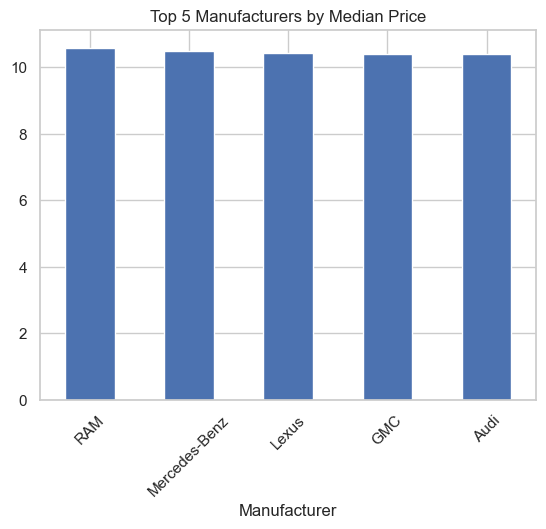

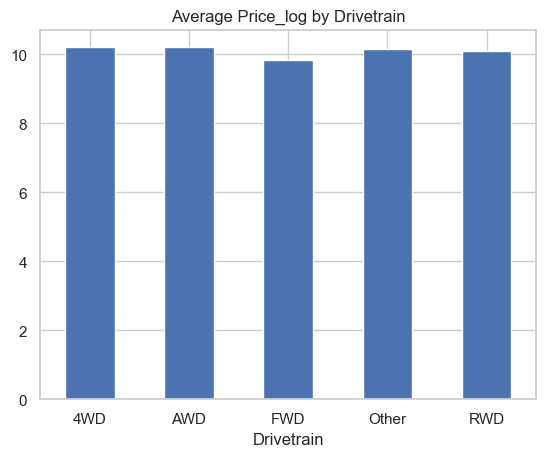

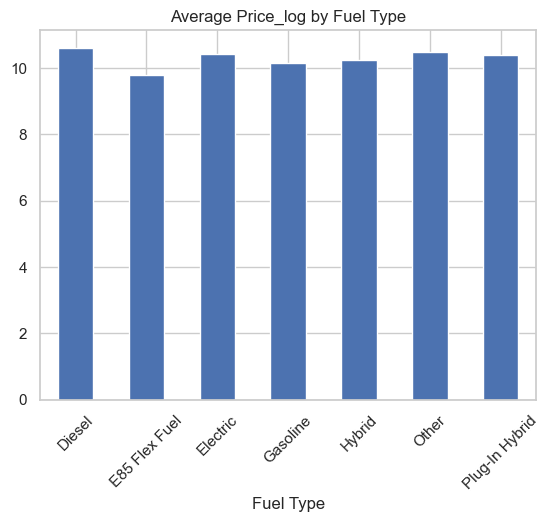

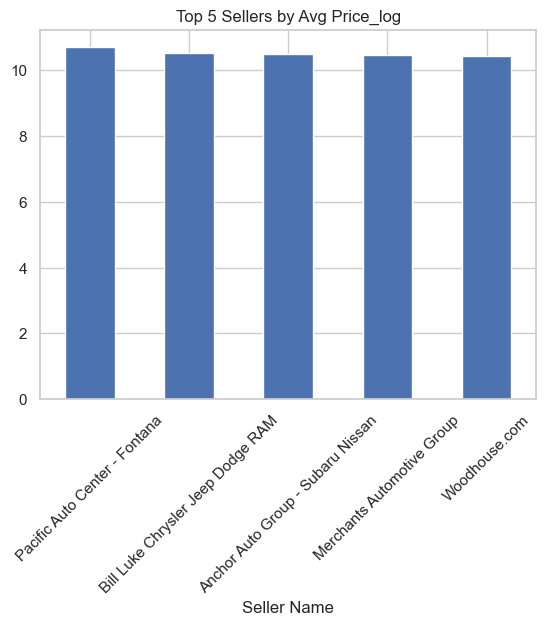

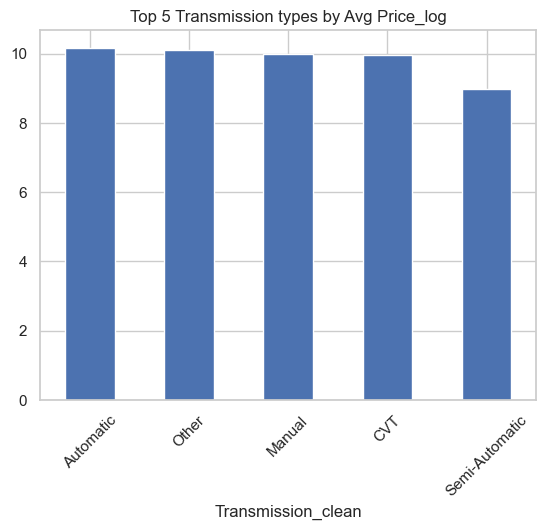

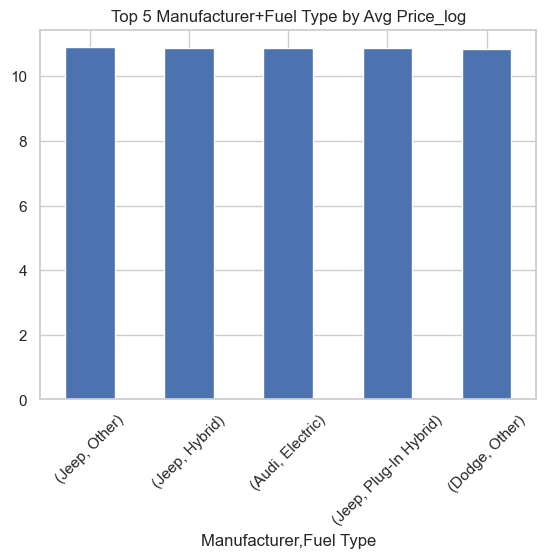

In [100]:
# Top 5 Manufacturers by median price
df.groupby("Manufacturer")["Price_log"].median() .sort_values(ascending=False).head(5).plot(kind='bar', title="Top 5 Manufacturers by Median Price")
plt.xticks(rotation=45)
plt.show()

# Average Price_log by Drivetrain
df.groupby('Drivetrain')['Price_log'].mean().plot(kind='bar', title="Average Price_log by Drivetrain")
plt.xticks(rotation=0)
plt.show()

# Average Price_log by Fuel Type
df.groupby('Fuel Type')['Price_log'].mean() .plot(kind='bar', title="Average Price_log by Fuel Type")
plt.xticks(rotation=45)
plt.show()

# Top 5 Sellers by Price_log
df.groupby("Seller Name")['Price_log'].mean().sort_values(ascending=False).head(5).plot(kind='bar', title="Top 5 Sellers by Avg Price_log")
plt.xticks(rotation=45)
plt.show()

# Top 5 Transmission types by Price_log
df.groupby("Transmission_clean")['Price_log'].mean().sort_values(ascending=False).head(5).plot(kind='bar', title="Top 5 Transmission types by Avg Price_log")
plt.xticks(rotation=45)
plt.show()

# Top 5 Manufacturer + Fuel Type combinations
df.groupby(["Manufacturer","Fuel Type"])["Price_log"] .mean().sort_values(ascending=False).head(5).plot(kind='bar', title="Top 5 Manufacturer+Fuel Type by Avg Price_log")
plt.xticks(rotation=45)
plt.show()

* Cars with automatic transmission tend to have higher prices compared to manual transmission vehicles.
we can see large number of the vehicles have lower mileage and lower prices.
*  we can see there is a clear negative correlation between the two variables, as 'Mileage_per_year' increases, 'Price' tends to decrease.
* The plot shows a strong negative association between vehicle age and price.As the age of the vehicle increases, it's price generally decreases.Most vehicles are relatively young and have lower prices. We can see several outliers, some new vihicles have very higher prices.
 * Hybrid,electric and diesel vehicles tend to have higher price compared to other fuel type vehicles.

#### Correlation check

In [101]:
df.corr(numeric_only=True)['Price_log'].sort_values()

Vehicle_Age_log          -0.660411
Mileage                  -0.659751
Vehicle_Age              -0.542706
Driver_Reviews_Num_log   -0.411491
Mileage_per_Year         -0.341558
Mileage_per_Year_log     -0.297054
Driver Reviews Num       -0.258337
Accidents Or Damage      -0.222027
Mpg_Clean                -0.220982
Engine_Size              -0.015841
Personal Use Only        -0.015541
Seller Rating             0.112588
Driver Rating             0.153492
One Owner                 0.326800
Price                     0.946988
Price_log                 1.000000
Name: Price_log, dtype: float64

Mileage & Vehicle Age → strongest negative correlation

One Owner → positive correlation with price

In [102]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.savefig(f"{save_folder}/correlation.png", dpi=300)
plt.close()

* Mileage, Vehicle age, driver reviews, Mileage per year are the strongest features in our dataset. High value in these features means lower saling price.
* Rest features except one owner are very weak predictors.
* Vehicles with a single owner tend to have higher resale values.

Correlation analysis shows that mileage (-0.66) and vehicle age (-0.54) have the strongest negative relationship with price, indicating that heavily used and older vehicles tend to have lower resale values. Mileage per year (-0.34) and accident history (-0.22) also show moderate negative relationships with price, while one-owner vehicles (0.33) tend to retain higher value.

Dropping the features which are not required

In [103]:
df.drop(columns=['Driver Reviews Num','Mileage_per_Year','Vehicle_Age','Price','Exterior Color','Interior Color','Seller Name'],inplace=True)

In [104]:
df.to_csv('/Users/niharikabisoyi/PyCharmMiscProject/UsedCarPricePrediction/data/cars_model.csv', index=False)

In [105]:
full_data = pd.read_csv("/Users/niharikabisoyi/PyCharmMiscProject/UsedCarPricePrediction/data/cars_model.csv")
#random sample of 5000 rows
sample_data = full_data.sample(n=50000, random_state=42)
#sample csv
sample_data.to_csv("/Users/niharikabisoyi/PyCharmMiscProject/UsedCarPricePrediction/data/sample_cars.csv", index=False)

print("Sample dataset created: data/sample_cars.csv")

Sample dataset created: data/sample_cars.csv
